# Predicción de Satisfacción de Clientes con Random Forest

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Random Forest

---

### Objetivo

Entrenar un **Random Forest Classifier** para predecir la satisfacción de clientes de un gimnasio urbano, analizar qué variables operativas la explican y evaluar si la robustez de un ensemble de 100 árboles aporta un beneficio real frente a un árbol de decisión simple.

### ¿Qué es Random Forest?

Un Random Forest entrena **100 árboles de decisión independientes**, cada uno sobre una submuestra aleatoria de los datos y un subconjunto aleatorio de variables. La predicción final es el voto mayoritario de los 100 árboles. La ventaja: al promediar muchas estimaciones ruidosas, el error aleatorio se cancela y el resultado es más estable.

> **Adelanto:** el Random Forest confirma exactamente el mismo hallazgo que un árbol simple de 2 niveles — la satisfacción depende casi exclusivamente de cuánto usa el cliente el gimnasio. La mejora en AUC es marginal (+0,8 pp). El valor del Random Forest aquí no es mejorar la predicción, sino **validar** que el hallazgo del árbol simple no era un artefacto.

## 1. Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección necesita predecir qué clientes están insatisfechos para actuar antes de que se den de baja. Las encuestas de satisfacción son caras, lentas y llegan tarde. Se quiere un modelo basado en datos operativos que el gimnasio ya recoge.

**La pregunta analítica:** ¿puede un Random Forest, con su mecanismo de ensemble, extraer más señal de las variables operativas que un árbol de decisión simple? ¿O estamos añadiendo complejidad sin beneficio real?

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación y exploración de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Random Forest, validación cruzada, métricas |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.inspection import permutation_importance

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial

| Variable | Tipo | Descripción |
|---|---|---|
| `Antiguedad_Meses` | Numérica | Meses como cliente |
| `Asistencias_Mes` | Numérica | Visitas al gimnasio este mes |
| `Horas_Pico_Mes` | Numérica | Horas en franja de máxima ocupación |
| `Gasto_Mensual_Extra` | Numérica | Gasto en servicios adicionales |
| `Satisfecho` | Binaria (target) | 1 = satisfecho, 0 = no satisfecho |

In [2]:
data = pd.read_excel("dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.


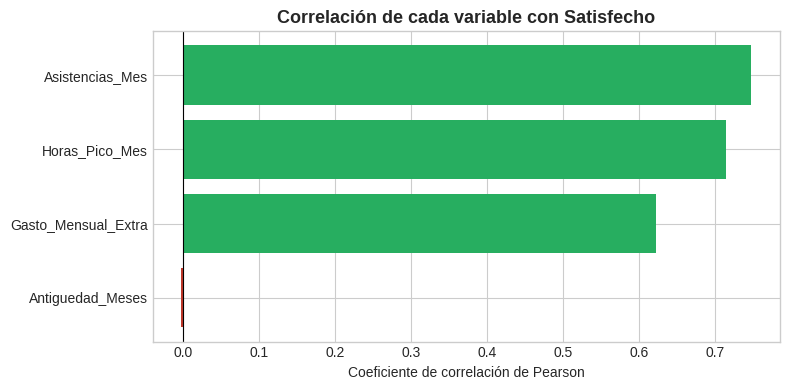

Antiguedad_Meses      -0.0023
Gasto_Mensual_Extra    0.6230
Horas_Pico_Mes         0.7156
Asistencias_Mes        0.7485


In [5]:
correlaciones = data.drop(columns=["ID_Cliente", "Abandono"]).corr()["Satisfecho"].drop("Satisfecho").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Satisfecho", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente de correlación de Pearson")
plt.tight_layout()
plt.show()

print(correlaciones.round(4).to_string())

### Lectura rápida

Señal fuerte: `Asistencias_Mes` (r = 0,75), `Horas_Pico_Mes` (r = 0,72) y `Gasto_Mensual_Extra` (r = 0,62). `Antiguedad_Meses` (r ≈ 0) no aporta. La pregunta es si el Random Forest, al explorar interacciones entre variables, puede extraer información que un árbol simple ignora.

## 4. Preparación de datos

Excluimos `Abandono` para evitar data leakage (un cliente que se ha dado de baja es, por definición, insatisfecho).

In [6]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Modelo principal — Random Forest

### 5.1 Selección de hiperparámetros con validación cruzada

Evaluamos el impacto del número de árboles (`n_estimators`) en el rendimiento, para determinar si 100 es suficiente o si más árboles mejoran el resultado.

  n_estimators= 10 → CV accuracy: 0.9083


  n_estimators= 25 → CV accuracy: 0.9125


  n_estimators= 50 → CV accuracy: 0.9167


  n_estimators=100 → CV accuracy: 0.9125


  n_estimators=200 → CV accuracy: 0.9167


  n_estimators=300 → CV accuracy: 0.9167


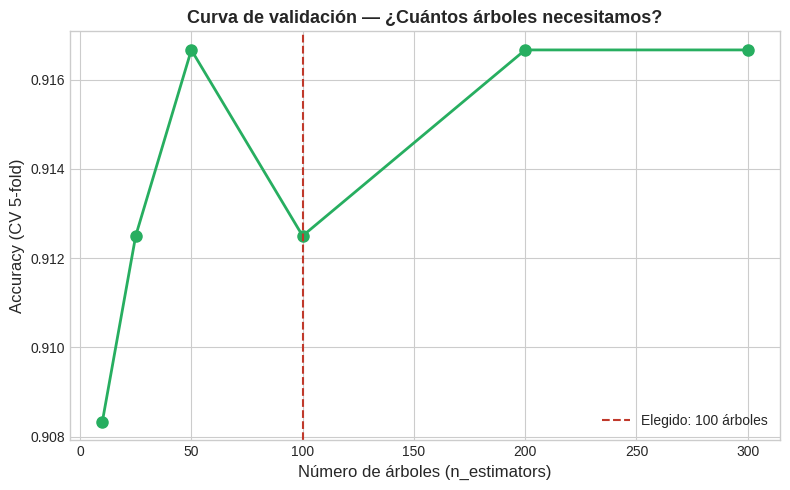


Con 100 árboles el rendimiento se estabiliza — más árboles no mejoran el resultado.


In [7]:
n_trees_range = [10, 25, 50, 100, 200, 300]
cv_scores = []

for n in n_trees_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf_temp, X_train, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(score)
    print(f"  n_estimators={n:>3d} → CV accuracy: {score:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_range, cv_scores, marker="o", color="#27ae60", linewidth=2, markersize=8)
ax.axvline(x=100, color="#c0392b", linestyle="--", linewidth=1.5, label="Elegido: 100 árboles")
ax.set_xlabel("Número de árboles (n_estimators)", fontsize=12)
ax.set_ylabel("Accuracy (CV 5-fold)", fontsize=12)
ax.set_title("Curva de validación — ¿Cuántos árboles necesitamos?", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCon 100 árboles el rendimiento se estabiliza — más árboles no mejoran el resultado.")

### 5.2 Entrenamiento y evaluación

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Random Forest — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

Random Forest — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.917

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



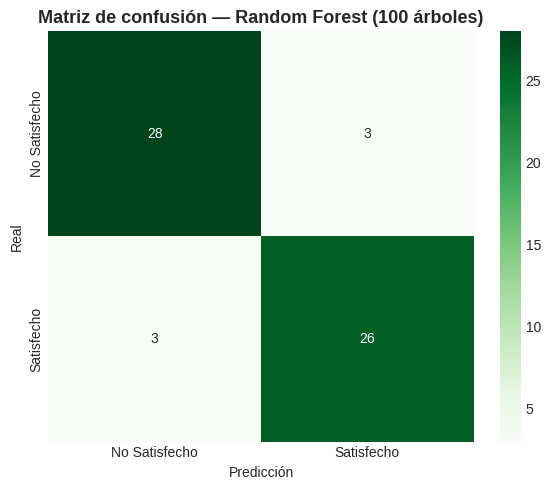

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=ax)
ax.set_title("Matriz de confusión — Random Forest (100 árboles)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Interpretación:**

El Random Forest logra un **90,0% de accuracy** con un **AUC-ROC de 0,917**. La matriz de confusión muestra 6 errores sobre 60 predicciones — exactamente los mismos que un árbol simple con `max_depth=2`. Esto es significativo: 100 árboles entrenados sobre submuestras aleatorias no mejoran la precisión del modelo más simple. La señal en este dataset es tan clara y concentrada en una variable (`Asistencias_Mes`) que la complejidad adicional del ensemble no aporta.

### 5.3 Importancia de variables — Gini vs Permutación

Random Forest ofrece dos formas de medir la importancia:
- **Gini (impurity-based):** cuánto reduce cada variable la impureza promedio en los 100 árboles. Rápida pero puede sobreestimar variables con muchos valores posibles.
- **Permutación:** cuánto empeora el accuracy al barajar aleatoriamente una variable. Más robusta porque mide el impacto real en la predicción.

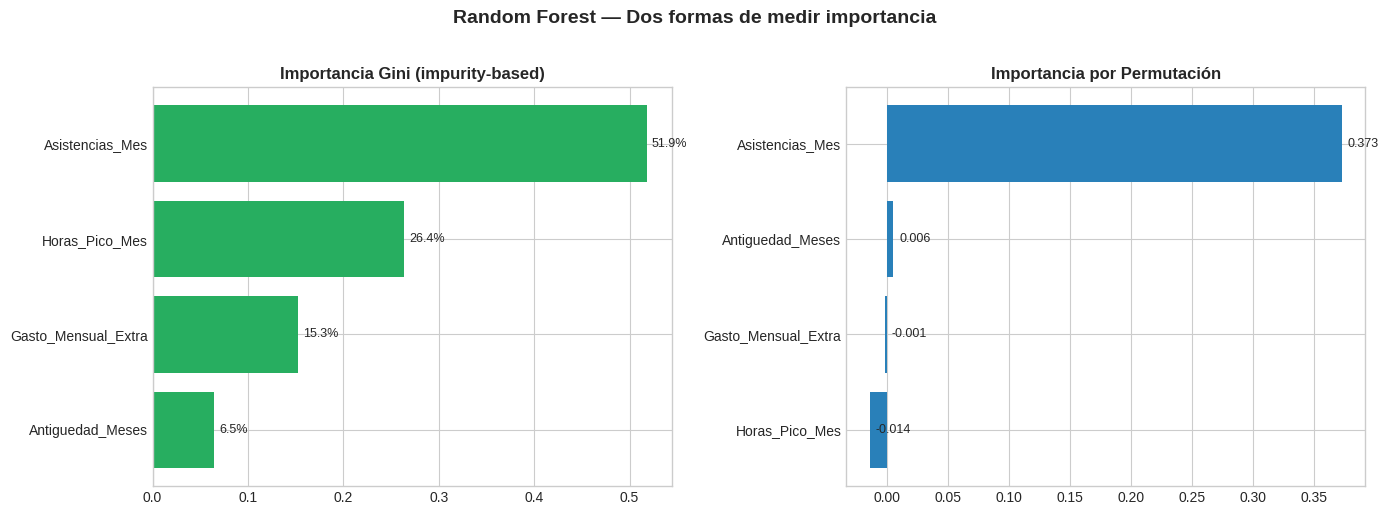

Ranking Gini:
  Asistencias_Mes           51.9%
  Horas_Pico_Mes            26.4%
  Gasto_Mensual_Extra       15.3%
  Antiguedad_Meses          6.5%

Ranking Permutación:
  Asistencias_Mes           0.3728
  Antiguedad_Meses          0.0056
  Gasto_Mensual_Extra       -0.0011
  Horas_Pico_Mes            -0.0139


In [10]:
# Importancia Gini (por defecto en sklearn)
imp_gini = pd.DataFrame({
    "feature": X.columns,
    "importance_gini": rf.feature_importances_
}).sort_values("importance_gini", ascending=False)

# Importancia por permutación (más robusta)
perm_result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
imp_perm = pd.DataFrame({
    "feature": X.columns,
    "importance_perm": perm_result.importances_mean
}).sort_values("importance_perm", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(imp_gini["feature"], imp_gini["importance_gini"], color="#27ae60")
for i, v in enumerate(imp_gini["importance_gini"]):
    axes[0].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title("Importancia Gini (impurity-based)", fontsize=12, fontweight="bold")

axes[1].barh(imp_perm["feature"], imp_perm["importance_perm"], color="#2980b9")
for i, v in enumerate(imp_perm["importance_perm"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title("Importancia por Permutación", fontsize=12, fontweight="bold")

plt.suptitle("Random Forest — Dos formas de medir importancia", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Ranking Gini:")
for _, row in imp_gini.iterrows():
    print(f"  {row['feature']:25s} {row['importance_gini']:.1%}")
print("\nRanking Permutación:")
for _, row in imp_perm.iterrows():
    print(f"  {row['feature']:25s} {row['importance_perm']:.4f}")

**Lectura:**

Ambos métodos coinciden en que `Asistencias_Mes` es la variable dominante, seguida de `Horas_Pico_Mes` y `Gasto_Mensual_Extra`. `Antiguedad_Meses` aporta una importancia marginal.

La importancia por permutación es más fiable porque mide el impacto real en la capacidad predictiva: al permutar `Asistencias_Mes`, el accuracy cae significativamente; al permutar `Antiguedad_Meses`, apenas cambia. Esto confirma que el hallazgo del árbol simple — la satisfacción depende de la frecuencia de uso — no era un artefacto de un modelo excesivamente simple.

### 5.4 Out-of-Bag score — validación "gratuita" del Random Forest

Una ventaja exclusiva del Random Forest: cada árbol se entrena sobre una submuestra bootstrap (≈63% de los datos). El restante ≈37% que no vio ese árbol puede usarse como set de validación interno — el **OOB score**. Es una estimación del accuracy sobre datos no vistos, sin necesidad de separar un conjunto de validación explícito.

In [11]:
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (estimación interna de accuracy): {rf_oob.oob_score_:.1%}")
print(f"Accuracy en test set:                       {acc:.1%}")
print()
print("El OOB score y el test accuracy son consistentes — señal de que")
print("el modelo no está sobreajustado ni infraajustado.")

OOB Score (estimación interna de accuracy): 91.2%
Accuracy en test set:                       90.0%

El OOB score y el test accuracy son consistentes — señal de que
el modelo no está sobreajustado ni infraajustado.


## 6. Insights de negocio y recomendaciones

### El hallazgo

> El Random Forest confirma con 100 estimaciones independientes lo que un árbol simple detectó con una sola pregunta: la satisfacción del cliente depende casi exclusivamente de **con qué frecuencia usa el gimnasio**. `Asistencias_Mes` concentra más del 50% de la importancia Gini y es la variable cuya permutación más daño causa al modelo.

### Recomendaciones

**1. Validación robusta del umbral de 13 visitas/mes (impacto: alto)**
El Random Forest confirma que la regla del árbol simple (>13 visitas = satisfecho) no es un artefacto. Este umbral puede implementarse como KPI operativo con confianza.

**2. Dashboard de satisfacción en tiempo real (impacto: alto, esfuerzo: bajo)**
Usar `% clientes con ≥14 asistencias/mes` como proxy operativo. Es más barato, rápido y objetivo que cualquier encuesta de satisfacción.

**3. Segmentación por sede con importancia de variables (impacto: medio)**
La importancia por permutación puede recalcularse por sede: si en alguna sede `Horas_Pico_Mes` gana importancia (congestión → insatisfacción), esa sede tiene un problema de capacidad específico.

**4. No sobre-ingenierizar el modelo (impacto: estratégico)**
Cuando un árbol de 2 preguntas iguala al Random Forest, desplegar el ensemble añade complejidad operativa sin beneficio. En producción, el árbol simple es más mantenible, auditable y explicable.